In [6]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [7]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play
from nanodrz.download import dl_scp_file
from nanodrz import format_conversions as format

ckpt = torch.load(dl_scp_file("gpudev:/home/harry/storj/runs/nanodrz/1706615262/0003000.pt"))

rsync --partial --progress --human-readable -e ssh gpudev:/home/harry/storj/runs/nanodrz/1706615262/0003000.pt /home/harry/storj/runs/nanodrz/1706615262/0003000.pt
0003000.pt

              0   0%    0.00kB/s    0:00:00  
        546.63M  43%  521.30MB/s    0:00:01  
        638.35M  50%  304.54MB/s    0:00:01  
          1.02G  81%  325.17MB/s    0:00:00  
          1.24G  98%  295.25MB/s    0:00:00  
          1.26G 100%  296.21MB/s    0:00:04 (xfr#1, to-chk=0/1)


In [8]:
config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

/home/harry/diarisation/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


In [9]:
print(config.model.use_time_pos)

True


[0.6916426420211792, 2.2478384971618652, 'A']
[2.334293842315674, 4.322766304016113, 'B']
[4.409221649169922, 6.743515491485596, 'A']
[7.4351582527160645, 9.423630714416504, 'B']
[9.596541404724121, 12.536023139953613, 'C']
[13.227664947509766, 14.78386116027832, 'B']


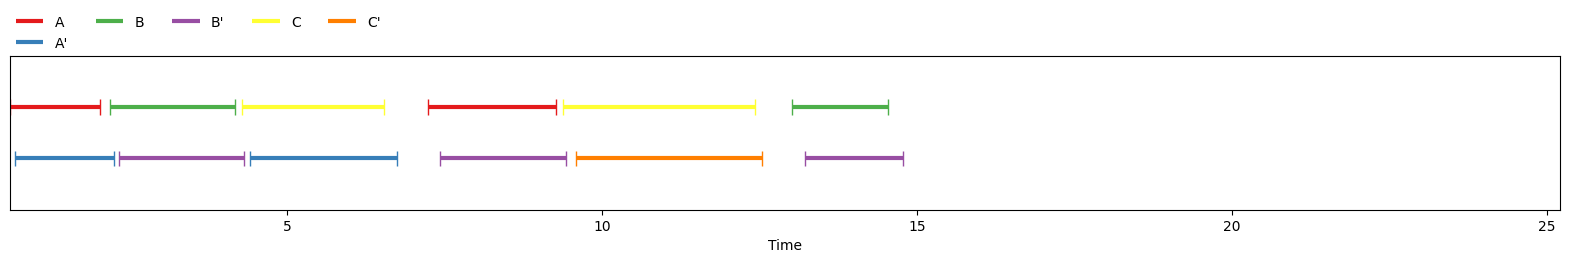

In [17]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(), **config.data.model_dump())
reference = format.labels_to_annotation(labels)
play(audio)


# Build the prompt version as the model could be choosing different speakers

nlabels = model.generate(audio.cuda(), temperature=1, max_steps=(len(labels))*3, top_p=.5)
print("\n".join([str(n) for n in nlabels]))

for l in nlabels:
    l[2] = l[2]+ "'"

hypothesis = visualise_annotation(labels+nlabels)

### Calculate Metrics with Pyannote


In [ ]:
from pyannote.core import Annotation
from pyannote.metrics.diarization import DiarizationErrorRate

metric = DiarizationErrorRate()
metric(reference, hypothesis)